In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [37]:
#loading reqs
from config import *
from utils import *

In [38]:
# model name to be included in file names later
title = 'Run'

def output_title(title, iterations, separator="_"):
    return f"{base_text}{separator}{iterations}"


In [39]:
# Real data input from Overview of modelling data_2024 (1)
#KOV: THIS NEEDS TO BE CHANGED FROM HARD CODE - WAITING FOR A SPREADSHEET FROM NIKKI
#My real data
# Load the Excel file into a DataFrame
real_df = pd.read_excel('coral_cover_data.xlsx', sheet_name='Sheet1')  # adjust sheet_name if needed

real_df = pd.DataFrame(real_data.head)

print(real_df)

    Year  RealBranching_Area (%)  RealFoliose_Area (%)  RealOther_Area (%)
0   2005                    1.20                  2.20                16.3
1   2006                    1.55                  2.20                17.4
2   2007                    1.90                  2.20                18.5
3   2008                    3.00                  2.45                17.4
4   2009                    4.10                  2.70                16.3
5   2010                    6.05                  2.70                15.2
6   2011                    8.00                  2.70                14.1
7   2012                   10.50                  2.55                13.5
8   2013                   13.00                  2.40                12.9
9   2014                   14.20                  2.70                17.2
10  2015                   19.10                  2.20                13.9
11  2016                   18.80                  2.80                15.4


In [40]:
#create all df's from the same 100 model runs


# Function to run the model 100 times and collect the results
def run_model_100_times():
    population_results = []
    percentage_population_results = []
    area_results = []
    final_results = []
    
    for _ in range(100):
        coral_model_results = run_coral_model(PSD_T0, MaxYear)
        benthic_cover_results = opts.yearly_benthic_cover_df
        rugosity_results = get_rugosity_list()
        
        # Merge the results into a single DataFrame
        merged_results = pd.merge(coral_model_results, benthic_cover_results, on='Year')
        merged_results['Rugosity'] = rugosity_results
        
        final_results.append(merged_results)
        
        # Collect population, percentage population, and area results
        for year in range(MaxYear + 1):
            population_df = opts.yearly_population_df_list[year]
            surface_area_df = opts.yearly_surface_area_df_list[year]
            
            for mg in ['Branching', 'Foliose', 'Other']:
                # Population Size DataFrame
                pop_size_row = [mg, year] + population_df[mg].tolist()
                population_results.append(pop_size_row)
                
                # Percentage Population Size DataFrame
                total_pop = population_df[mg].sum()
                perc_pop_size_row = [mg, year] + (100 * population_df[mg] / total_pop).tolist()
                percentage_population_results.append(perc_pop_size_row)
                
                # Area DataFrame
                area_row = [mg, year] + surface_area_df[mg].tolist()
                area_results.append(area_row)
    
    # Concatenate all the results into a single DataFrame
    final_df = pd.concat(final_results)
    
    return final_df, population_results, percentage_population_results, area_results

# Run the model 100 times and get the results
final_df, population_results, percentage_population_results, area_results = run_model_100_times()

# Create dataframes for population size, percentage population size, and area
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]

population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)


Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.600000          7.300000        8.000000   
1      1            1.248691          4.578383        6.131129   
2      2            1.370878          4.978009        6.436428   
3      3            1.536935          5.470033        6.765692   
4      4            1.735700          6.074119        7.127565   
..   ...                 ...               ...             ...   
15    15            1.915998          8.545309        6.721899   
16    16            2.212202         10.006856        7.247487   
17    17            2.240819         10.753132        7.420579   
18    18            2.516563         12.393200        7.942751   
19    19            1.502653          9.168611        6.656289   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               17.900000                89.100000                43.300000   
1               11.958203        

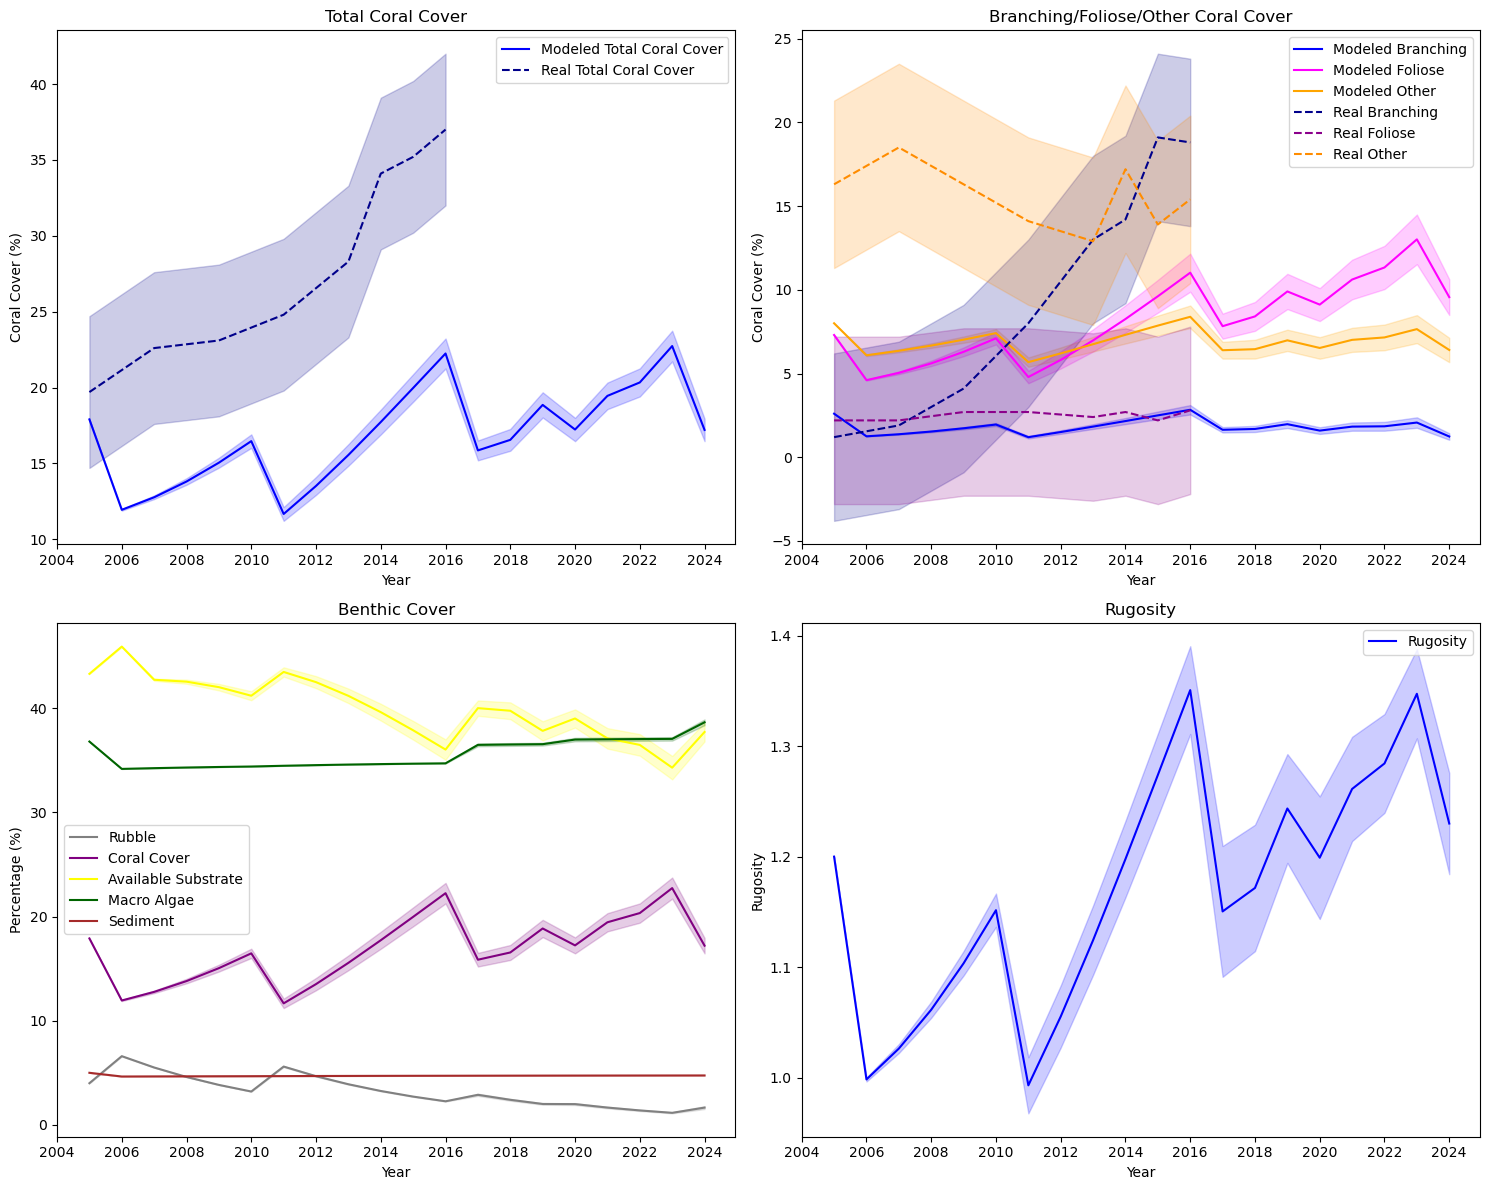

In [41]:
#plating 2x2 cc, mg, rug, benthic

# Assuming final_df and real_df are already defined DataFrames
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total, label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, average_total - std_dev_total, average_total + std_dev_total, color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'], real_df['Total_Coral_Cover (%)'], label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'], real_df['Total_Coral_Cover (%)'] - real_total_margin, real_df['Total_Coral_Cover (%)'] + real_total_margin, color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other, label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealBranching_Area (%)'], label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealBranching_Area (%)'] - real_branching_margin, real_df['RealBranching_Area (%)'] + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealFoliose_Area (%)'], label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealFoliose_Area (%)'] - real_foliose_margin, real_df['RealFoliose_Area (%)'] + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealOther_Area (%)'], label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealOther_Area (%)'] - real_other_margin, real_df['RealOther_Area (%)'] + real_other_margin, color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()



In [42]:
def plot_bubble_chart_from_dataframe(df, title, category_col='MG', year_interval=4, year_start=2000, bubble_scale=100, parallel_offset = 1.2, figsize=(18, 12), x_spacing=1.5, y_spacing=5):
    """
    Create a bubble chart showing population distribution by category over time.
    
    Parameters:
    - df: DataFrame with columns for category, year, and bin data (percentages)
    - y_label: Label for y-axis (default: "Bin Size")
    - y_unit: Unit for y-axis (default: "cm")
    - category_col: Column name for categories (default: 'MG')
    - year_interval: Select every Nth year (default: 4 for every 4th year)
    - year_start: Starting year for converting model years to actual years (default: 2000)
    - bubble_scale: Multiplier for bubble sizes (default: 100)
    
    Expected DataFrame structure:
    - Column 0: Category (MG)
    - Column 1: Year (model years: 0, 1, 2, 3, ...)
    - Columns 2+: Bin diameter columns (5, 10, 15, ..., 100) with percentages
    """
    
    # Configuration parameters
    parallel_offset = parallel_offset  # Horizontal offset between categories
    
    # Get actual bin diameter columns (columns 2 onwards contain bin data)
    bin_columns = df.columns[2:].tolist()  # Skip category and year columns
    
    # Extract bin diameters from column names (assuming they contain numeric values)
    bin_diameters = []
    for col in bin_columns:
        # Extract numeric value from column name (e.g., "Bin_5" -> 5, "5cm" -> 5, etc.)
        import re
        numbers = re.findall(r'\d+', str(col))
        if numbers:
            bin_diameters.append(float(numbers[0]))
        else:
            # If no number found, use column index * 5 (assuming 5cm increments)
            bin_diameters.append((len(bin_diameters)) * 5 + 5)
    
    MaxBinId = len(bin_diameters)
    
    # Get unique years and categories from the data
    if 'Year' in df.columns:
        all_years_list = sorted(df['Year'].unique().tolist())
    else:
        all_years_list = [0, 4, 7, 11]
    
    # Select every Nth year to reduce clutter - filter by year values, not array indices
    if year_interval > 1:
        # Select years that are multiples of the interval
        years = [year for year in all_years_list if year % year_interval == 0]
    else:
        # If interval is 1, use all years
        years = all_years_list.copy()
    
    print(f"All years in data: {all_years_list}")
    print(f"Selected years (multiples of {year_interval}): {years}")
    
    # Convert model years to actual years
    actual_years = [year + year_start for year in years]
    print(f"Actual years for display: {actual_years}")
    
    categories = sorted(df[category_col].unique()) if category_col in df.columns else ['Branching', 'Foliose', 'Other']
    
    # Color schemes for each category
    color_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD93D', '#6BCF7F', '#FF8C42']
    colors = {}
    for i, category in enumerate(categories):
        base_color = color_palette[i % len(color_palette)]
        colors[category] = {
            'mean': base_color,
            'std': base_color + '40'  # Add transparency for std
        }
    
    # Calculate category offsets for parallel display
    category_offsets = {}
    if len(categories) == 1:
        category_offsets[categories[0]] = 0
    elif len(categories) == 2:
        category_offsets[categories[0]] = -parallel_offset/2
        category_offsets[categories[1]] = parallel_offset/2
    else:  # 3 or more categories
        for i, cat in enumerate(categories):
            category_offsets[cat] = (i - (len(categories)-1)/2) * parallel_offset
    
    # Prepare data for plotting
    plot_data = []
    
    for category in categories:
        for model_year in years:  # Use model years for filtering data
            actual_year = model_year + year_start  # Convert to actual year for positioning
            # Filter data for this category and model year
            year_df = df[(df[category_col] == category) & (df['Year'] == model_year)]
            
            if not year_df.empty:
                # Get bin data (columns 2 onwards contain the percentage data)
                bin_data = year_df.iloc[:, 2:]  # All bin columns
                
                # Calculate mean and std for each bin across all rows for this category/year
                mean_values = bin_data.mean(axis=0)
                std_values = bin_data.std(axis=0)
                
                # Create data points for each bin using actual bin diameters
                for bin_idx, (col_name, mean_val, std_val) in enumerate(zip(bin_columns, mean_values, std_values)):
                    if bin_idx < len(bin_diameters):
                        # Convert to float and check if valid
                        try:
                            mean_val = float(mean_val) if pd.notna(mean_val) else 0
                            std_val = float(std_val) if pd.notna(std_val) else 0
                        except (ValueError, TypeError):
                            mean_val = 0
                            std_val = 0
                        
                        # Always define position variables
                        x_pos = actual_year + category_offsets[category]  # Use actual year for positioning
                        y_pos = bin_diameters[bin_idx]  # Use actual bin diameter from column
                        
                        if mean_val > 0:
                            # Add mean point (main bubble)
                            plot_data.append({
                                'x': x_pos,
                                'y': y_pos,
                                'size': mean_val,
                                'color': colors[category]['mean'],
                                'category': category,
                                'year': actual_year,  # Store actual year
                                'type': 'mean',
                                'bin_idx': bin_idx
                            })
                        
                        # Add std point (background shading) if std exists
                        if std_val > 0:
                            plot_data.append({
                                'x': x_pos,
                                'y': y_pos,
                                'size': std_val,
                                'color': colors[category]['std'],
                                'category': category,
                                'year': actual_year,  # Store actual year
                                'type': 'std',
                                'bin_idx': bin_idx
                            })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Group data by position for proper std shading around mean
    position_data = {}
    for point in plot_data:
        key = (point['x'], point['y'], point['category'])
        if key not in position_data:
            position_data[key] = {'mean': None, 'std': None}
        position_data[key][point['type']] = point
    
    # Plot standard deviation as shading around mean bubbles
    for (x, y, category), data in position_data.items():
        if data['mean'] is not None:
            mean_point = data['mean']
            
            # Plot mean bubble
            ax.scatter(
                mean_point['x'], 
                mean_point['y'], 
                s=float(mean_point['size']) * bubble_scale,  # Ensure float conversion
                c=mean_point['color'],
                alpha=0.8,
                edgecolors='black',
                linewidth=0.5,
                zorder=2,
                label=f'{category}' if mean_point['bin_idx'] == 0 and mean_point['year'] == actual_years[0] else ""
            )
            
            # Plot std shading around the mean if std data exists
            if data['std'] is not None:
                std_point = data['std']
                # Create larger bubble for std shading
                std_size = float(mean_point['size']) + float(std_point['size'])  # Ensure float conversion
                
                ax.scatter(
                    std_point['x'], 
                    std_point['y'], 
                    s=std_size * bubble_scale,  # Use configurable scale factor
                    c=std_point['color'],
                    alpha=0.2,  # Very light for background
                    edgecolors='none',
                    zorder=1
                )
    
    # Add vertical lines to separate years (optional) - position at actual years
    if len(actual_years) > 1:
        for i in range(len(actual_years)-1):
            separator_x = (actual_years[i] + actual_years[i+1]) / 2
            ax.axvline(x=separator_x, color='lightgray', linestyle='--', alpha=0.5)
    
    # Customize plot appearance
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Bin diameter (cm)', fontsize=14, fontweight='bold')
    
    # Set x-axis ticks and labels with actual years - more robust approach
    ax.set_xticks(actual_years)
    
    # Create distinct labels for each year
    year_labels = []
    for actual_year in actual_years:
        year_labels.append(str(int(actual_year)))
    
    ax.set_xticklabels(year_labels, rotation=0, ha='center')
    
    # Force the x-axis to show the full range with proper spacing
    if len(actual_years) > 1:
        year_span = max(actual_years) - min(actual_years)
        margin = max(1, year_span * 0.1)  # 10% margin
        ax.set_xlim(min(actual_years) - margin, max(actual_years) + margin)
    else:
        ax.set_xlim(actual_years[0] - 1, actual_years[0] + 1)
    
    # Ensure ticks are visible and properly spaced
    ax.tick_params(axis='x', labelsize=12)
    
    # Update title to reflect actual year range
    if len(actual_years) > 1:
        year_range = f"({actual_years[0]}-{actual_years[-1]})"
    else:
        year_range = f"({actual_years[0]})"
    
    ax.set_title(f'{title} by Category Over Time {year_range}\n(Bubble size represents {title})', fontsize=16, fontweight='bold', pad=20)

    
    # Set y-axis to show actual bin diameters from your data
    #if len(bin_diameters) > 0:
       # ax.set_ylim(min(bin_diameters) - 2.5, max(bin_diameters) + 2.5)
        # Use actual bin diameters for y-axis ticks
        #ax.set_yticks(bin_diameters)
        #ax.set_yticklabels([f'{int(diameter)}' for diameter in bin_diameters])

# Set y-axis to show actual bin diameters with custom spacing
    if len(bin_diameters) > 0:
        ax.set_ylim(min(bin_diameters) - y_spacing, max(bin_diameters) + y_spacing)
        # Use actual bin diameters for y-axis ticks
        ax.set_yticks(bin_diameters)
        ax.set_yticklabels([f'{int(diameter)}' for diameter in bin_diameters])
    

    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Create legend
    legend_elements = []
    for category in categories:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=colors[category]['mean'], 
                                        markersize=10, label=f'{category}',
                                        markeredgecolor='black', markeredgewidth=0.5))
    
    # Add legend with better positioning
    ax.legend(handles=legend_elements, loc='upper right', frameon=True, 
              fancybox=True, shadow=True, fontsize=12)

    # Define the graph directory path
    graph_dir = r'output/figures'

    # Save the combined plot to the specified folder
    graph_path = os.path.join(graph_dir, f'{title} bubble_graph.png')
    plt.savefig(graph_path)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()
    
    
    return fig, ax

# Example usage:
# df = pd.DataFrame({
#     'MG': ['Branching', 'Branching', 'Foliose', 'Foliose'],
#     'Year': [0, 4, 0, 4],  # Model years
#     '5': [10.5, 15.2, 8.1, 12.3],    # 5cm diameter bin
#     '10': [20.3, 25.1, 18.4, 22.7],  # 10cm diameter bin
#     '15': [30.2, 35.8, 28.9, 32.1],  # 15cm diameter bin
#     '20': [15.1, 12.4, 22.3, 18.9],  # 20cm diameter bin
#     # ... more diameter bins up to 100cm
# })

# Basic usage with default bubble scale (100)
# plot_bubble_chart_from_dataframe(df, "Coral Diameter", "cm", "MG", year_start=2000)

# Custom bubble scale for smaller bubbles
# plot_bubble_chart_from_dataframe(df, "Coral Diameter", "cm", "MG", year_start=2000, bubble_scale=50)

# Custom bubble scale for larger bubbles
# plot_bubble_chart_from_dataframe(df, "Coral Diameter", "cm", "MG", year_start=2000, bubble_scale=200)

# All parameters customized
# plot_bubble_chart_from_dataframe(df, "Coral Diameter", "cm", "MG", 
#                                 year_interval=2, year_start=1995, bubble_scale=150)

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


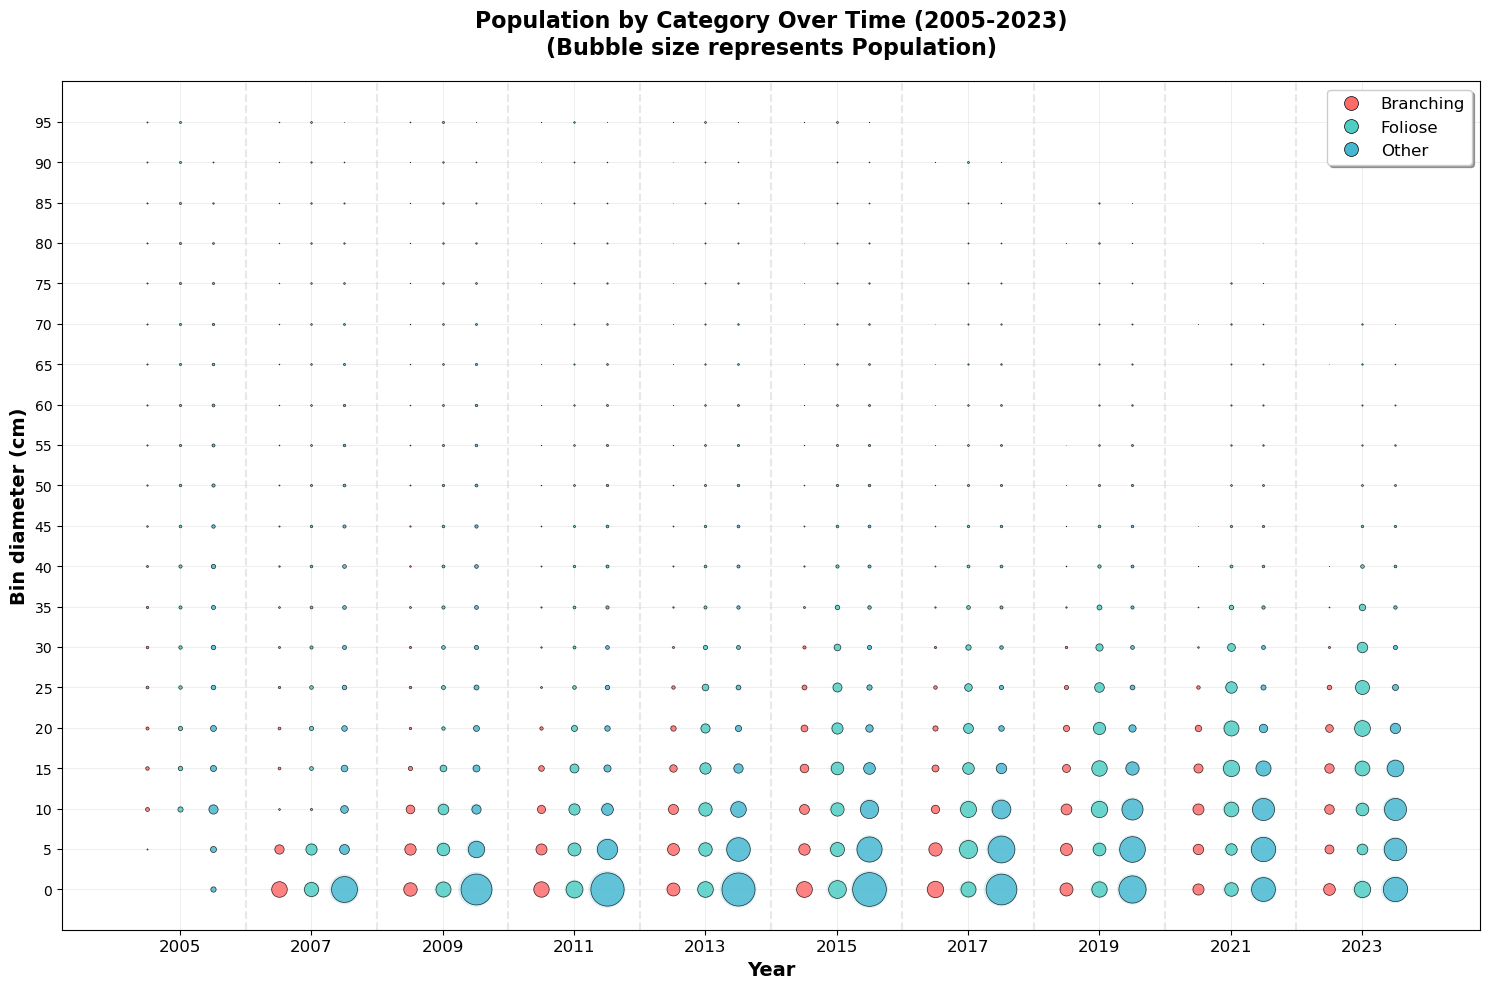

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population by Category Over Time (2005-2023)\n(Bubble size represents Population)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [43]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                year_interval=2, 
                                year_start=year_start, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.08,       # More x-spacing
                                y_spacing=5)         # More y-spacing

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


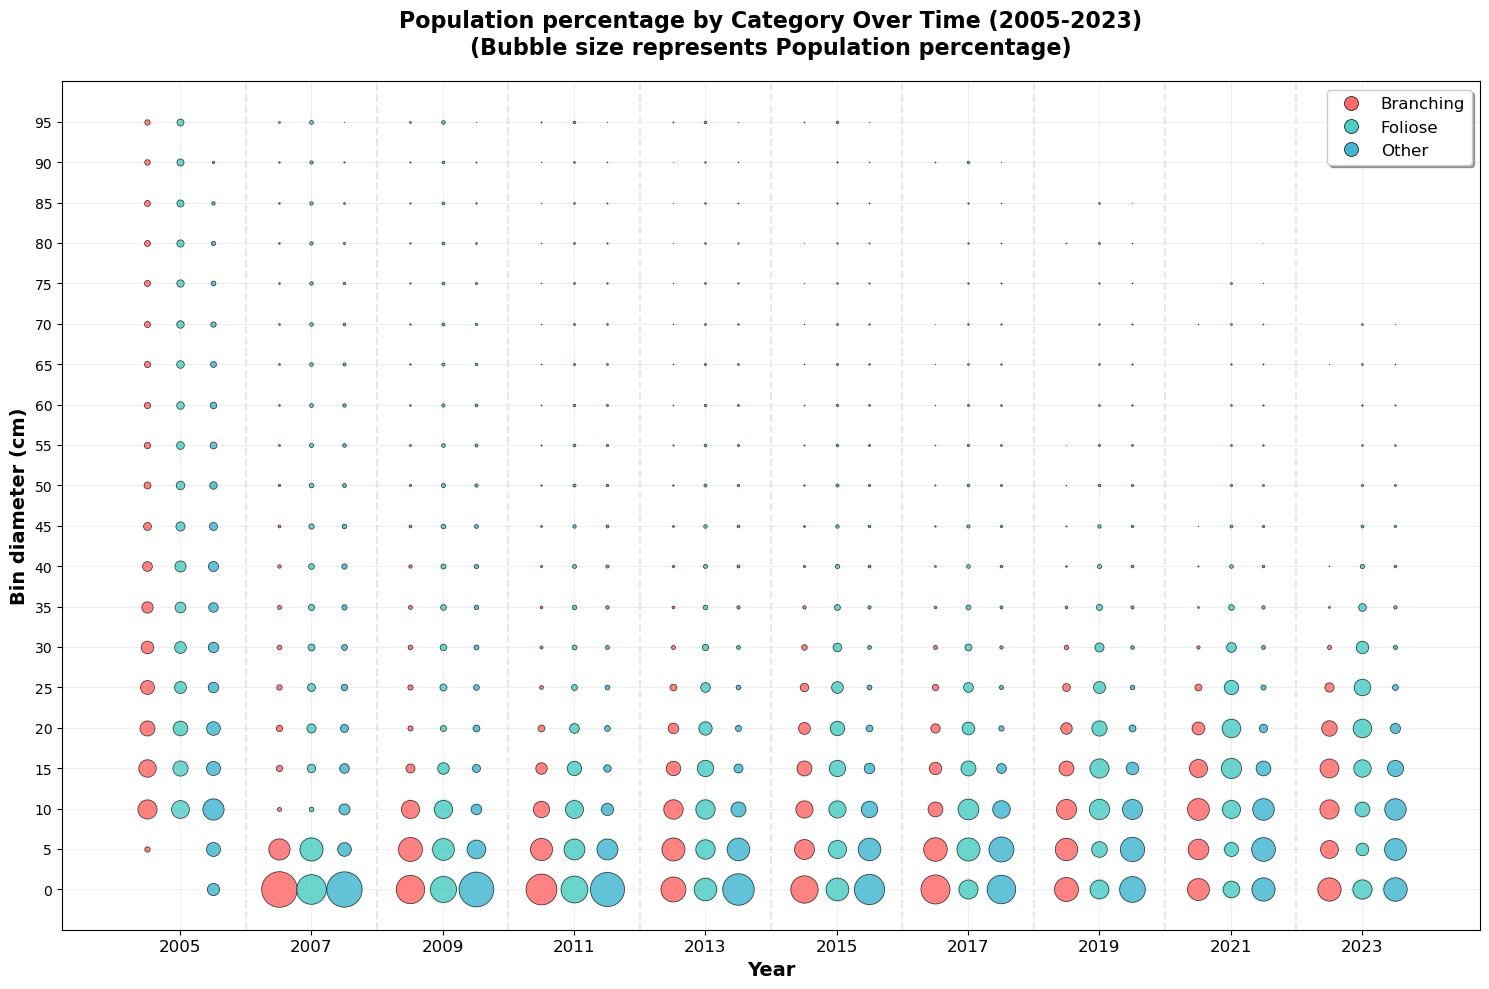

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population percentage by Category Over Time (2005-2023)\n(Bubble size represents Population percentage)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [44]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                year_interval=2, 
                                year_start=year_start, 
                                bubble_scale=10,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.05,       # More x-spacing
                                y_spacing=5)         # More y-spacing

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


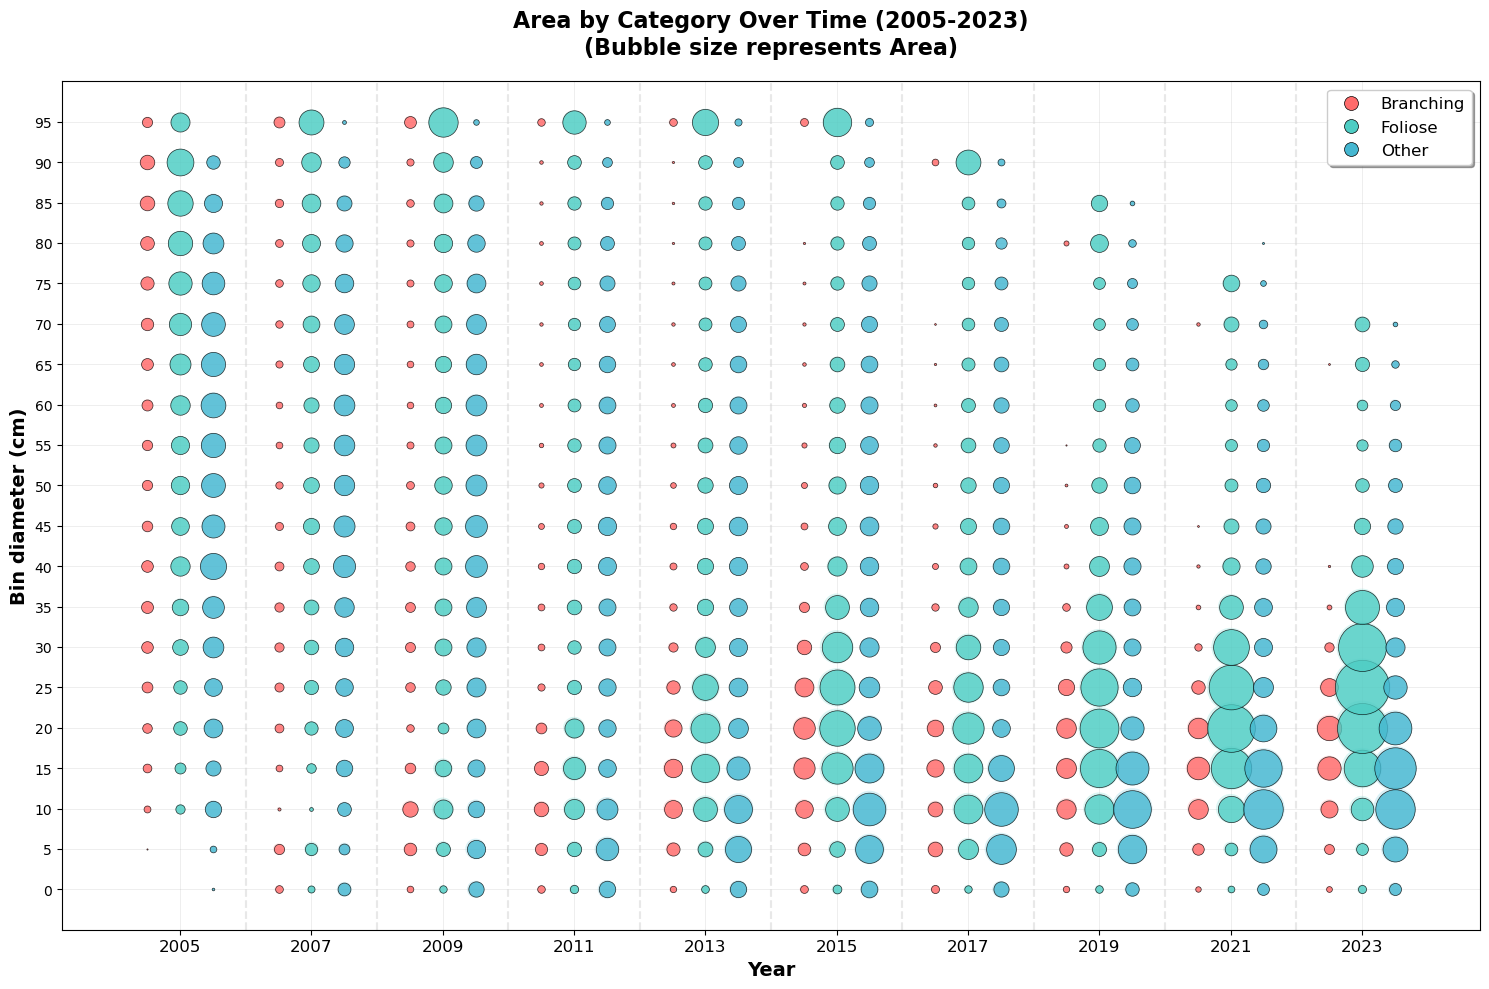

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Area by Category Over Time (2005-2023)\n(Bubble size represents Area)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [45]:
plot_bubble_chart_from_dataframe(area_df, 
                                title = "Area",
                                category_col="MG", 
                                year_interval=2, 
                                year_start=year_start, 
                                bubble_scale=5,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.05,       # More x-spacing
                                y_spacing=5)         # More y-spacing